# Stage 1: Exploratory Data Analysis (EDA) — CORRECTED SCHEMA
**Cloud Resource Optimisation Thesis — Frankfurt School of Finance and Management**  
**Author:** Pinki Kumari 
**Date:** April 2026  

---

## Purpose
Quantify the **over-provisioning gap** between requested resources (`batch_task`) and actual usage (`batch_instance`) using the **corrected column mappings** from `data_mapping.ipynb`.

## Research Questions
1. **RQ1:** What is the average CPU utilization across all jobs?
2. **RQ2:** How significant is the over-provisioning gap across different job sizes?
3. **RQ3:** What cost savings can be achieved by rightsizing to actual usage + buffer?

## Key Corrections from Original Stage 1
- ✅ Fixed join key: `job_name` (column 2, not column 1)
- ✅ Fixed unit conversion: `plan_cpu` uses 100=1core, `cpu_avg` already in cores
- ✅ Removed `machine_id` and memory columns (don't exist / all NULL)
- ✅ Clarified `instance_name` as the instance identifier for this notebook pipeline

---

## Data Source
**Google Drive:** `Thesis Cloud > ProcessedData2018`
- `batch_task_corrected.csv`
- `batch_instance_corrected.csv`
- `SCHEMA_REFERENCE.csv` - column documentation

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
BASE_DIR = Path(r"E:/Cloud_Resource_Optimisation_thesis")
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
RAW_DIR = BASE_DIR / 'data' / 'raw' / 'clusterdata2018' / 'trace_201708'

bt_path = PROCESSED_DIR / 'batch_task_corrected.csv'
bi_path = PROCESSED_DIR / 'batch_instance_corrected.csv'

if bt_path.exists() and bi_path.exists():
    bt = pd.read_csv(bt_path)
    bi = pd.read_csv(bi_path)
    data_source = 'processed corrected files'
else:
    bt_raw = RAW_DIR / 'batch_task.csv'
    bi_raw = RAW_DIR / 'batch_instance.csv'

    bt_cols = [
        'task_name', 'instance_name', 'job_name', 'task_id',
        'start_time', 'status', 'plan_cpu', 'plan_mem'
    ]
    bi_cols = [
        'instance_name', 'task_name', 'job_name', 'task_id',
        'start_time', 'status', 'seq_no', 'total_seq_no',
        'cpu_max', 'cpu_avg', 'mem_max', 'mem_avg'
    ]

    bt = pd.read_csv(bt_raw, header=None, names=bt_cols)
    bi = pd.read_csv(bi_raw, header=None, names=bi_cols)
    data_source = 'raw trace files with corrected schema mapping'

print('=' * 70)
print('DATA LOADED')
print('=' * 70)
print('Base directory      :', BASE_DIR)
print('Data source         :', data_source)
print('Processed directory :', PROCESSED_DIR)
print('Raw directory       :', RAW_DIR)

DATA LOADED
Base directory      : E:\Cloud_Resource_Optimisation_thesis
Data source         : raw trace files with corrected schema mapping
Processed directory : E:\Cloud_Resource_Optimisation_thesis\data\processed
Raw directory       : E:\Cloud_Resource_Optimisation_thesis\data\raw\clusterdata2018\trace_201708


In [5]:
print(f"\nbatch_task: {bt.shape[0]:,} rows × {bt.shape[1]} columns")
print(f"batch_instance: {bi.shape[0]:,} rows × {bi.shape[1]} columns")

print(f"\nUnique jobs in batch_task: {bt['job_name'].nunique():,}")
print(f"Unique jobs in batch_instance: {bi['job_name'].nunique():,}")


batch_task: 80,553 rows × 8 columns
batch_instance: 16,094,656 rows × 12 columns

Unique jobs in batch_task: 12,951
Unique jobs in batch_instance: 12,951


In [6]:
print(f"\nbatch_task: {bt.shape[0]:,} rows × {bt.shape[1]} columns")
print(f"batch_instance: {bi.shape[0]:,} rows × {bi.shape[1]} columns")

print(f"\nUnique jobs in batch_task: {bt['job_name'].nunique():,}")
print(f"Unique jobs in batch_instance: {bi['job_name'].nunique():,}")

print(f"\nFirst 3 rows of batch_task:")
print(bt.head(3))

print(f"\nFirst 3 rows of batch_instance:")
print(bi.head(3))


batch_task: 80,553 rows × 8 columns
batch_instance: 16,094,656 rows × 12 columns

Unique jobs in batch_task: 12,951
Unique jobs in batch_instance: 12,951

First 3 rows of batch_task:
   task_name  instance_name  job_name  task_id  start_time      status  \
0       6459           6524         3        4       15740  Terminated   
1       6457           6533         3        5           1  Terminated   
2       6036           6046         4        7         393     Waiting   

   plan_cpu  plan_mem  
0      50.0  0.007957  
1      50.0  0.004395  
2       NaN       NaN  

First 3 rows of batch_instance:
   instance_name  task_name  job_name  task_id  start_time      status  \
0          41562      41618     120.0    686.0       299.0  Terminated   
1          41561      41619     120.0    686.0      1279.0  Terminated   
2          41562      41617     120.0    686.0       828.0  Terminated   

   seq_no  total_seq_no  cpu_max  cpu_avg  mem_max  mem_avg  
0       1             1     1.5

In [7]:
# Join batch_task and batch_instance after adding source suffixes to every column
task_part = bt.copy().add_suffix('_task')
instance_part = bi.copy().add_suffix('_instance')

join_keys_left = ['job_name_task','task_name_task', 'instance_name_task' , 'task_id_task']
join_keys_right = ['job_name_instance', 'task_name_instance', 'instance_name_instance', 'task_id_instance']

joined_df = pd.merge(
    task_part,
    instance_part,
    left_on=join_keys_left,
    right_on=join_keys_right,
    how='inner'
 )

output_path = PROCESSED_DIR / 'joined_df_V2.xlsx'
joined_df.to_excel(output_path, index=False)

print(f"Joined rows: {len(joined_df):,}")
print(f"Joined columns: {joined_df.shape[1]}")
print(f"Saved Excel file: {output_path}")

print("\nColumns in task_part:")
print(task_part.columns.tolist())

print("\nColumns in instance_part:")
print(instance_part.columns.tolist())

print("\nColumns in joined_df:")
print(joined_df.columns.tolist())

print("\nSample rows:")
print(joined_df.head(5))

Joined rows: 3,200
Joined columns: 20
Saved Excel file: E:\Cloud_Resource_Optimisation_thesis\data\processed\joined_df_V2.xlsx

Columns in task_part:
['task_name_task', 'instance_name_task', 'job_name_task', 'task_id_task', 'start_time_task', 'status_task', 'plan_cpu_task', 'plan_mem_task']

Columns in instance_part:
['instance_name_instance', 'task_name_instance', 'job_name_instance', 'task_id_instance', 'start_time_instance', 'status_instance', 'seq_no_instance', 'total_seq_no_instance', 'cpu_max_instance', 'cpu_avg_instance', 'mem_max_instance', 'mem_avg_instance']

Columns in joined_df:
['task_name_task', 'instance_name_task', 'job_name_task', 'task_id_task', 'start_time_task', 'status_task', 'plan_cpu_task', 'plan_mem_task', 'instance_name_instance', 'task_name_instance', 'job_name_instance', 'task_id_instance', 'start_time_instance', 'status_instance', 'seq_no_instance', 'total_seq_no_instance', 'cpu_max_instance', 'cpu_avg_instance', 'mem_max_instance', 'mem_avg_instance']

Samp

---
## Step 1: Join, Filter, and Aggregate (Terminated + Non-Terminated Detail)

This step first splits both datasets into `Terminated` and non-terminated records.
The terminated subset is used for the main utilization analysis, while the non-terminated subset is kept in a separate detailed dataframe for inspection.

Then `plan_cpu` from `batch_task` is converted to actual cores using:
- `plan_cpu_cores = plan_cpu / 100` (because 100 CPU units = 1 core)

After filtering and conversion, the workflow creates four views:
- **Detailed terminated join** on `job_name + task_name + instance_name + task_id`
- **Detailed non-terminated join** on the same four-key row identity
- **Job-level aggregated view** grouped by `job_name`
- **Task-level aggregated view** grouped by `job_name + task_name`

For `batch_instance`, aggregation uses:
- `cpu_avg: sum` → total average CPU across all matched instances
- `cpu_max: sum` → total peak CPU across all matched instances
- `instance_name: count` → number of matched instances

The aggregated terminated views are then joined with the corresponding `batch_task` aggregates to compute utilization ratios (average and peak).

This gives a clean comparison between requested CPU cores and observed usage at both job granularity and task granularity, while still preserving detailed non-terminated rows for separate analysis.

In [13]:
print("=" * 70)
print("STEP 1: JOIN AND CLEAN DATA")
print("=" * 70)

# Split both datasets into terminated and non-terminated records.
bt_terminated = bt[bt['status'] == 'Terminated'].copy()
bi_terminated = bi[bi['status'] == 'Terminated'].copy()
bt_non_terminated = bt[bt['status'] != 'Terminated'].copy()
bi_non_terminated = bi[bi['status'] != 'Terminated'].copy()

print("\nRecord split:")
print(f"  batch_task terminated     : {len(bt_terminated):,}")
print(f"  batch_task non-terminated : {len(bt_non_terminated):,}")
print(f"  batch_instance terminated     : {len(bi_terminated):,}")
print(f"  batch_instance non-terminated : {len(bi_non_terminated):,}")

# Convert requested CPU units in batch_task into actual CPU cores (100 units = 1 core).
bt_terminated['plan_cpu_cores'] = bt_terminated['plan_cpu'] / 100
bt_non_terminated['plan_cpu_cores'] = bt_non_terminated['plan_cpu'] / 100

# Join the detailed terminated rows using the full row identity.
# The four-key join keeps the task and instance row aligned by job, task, instance, and task_id.
detail_join_keys = ['job_name', 'task_name', 'instance_name', 'task_id']
merged_detail = pd.merge(
    bt_terminated,
    bi_terminated,
    on=detail_join_keys,
    how='inner',
    suffixes=('_task', '_instance')
)

# Create a separate detailed dataframe for non-terminated rows using the same row identity.
# This lets us inspect unfinished work without mixing it into the terminated analysis.
merged_non_terminated_detail = pd.merge(
    bt_non_terminated,
    bi_non_terminated,
    on=detail_join_keys,
    how='inner',
    suffixes=('_task', '_instance')
)

# Aggregate non-terminated instance usage per job_name for reporting consistency.
bi_agg_non_terminated = bi_non_terminated.groupby('job_name').agg({
    'cpu_avg': 'max',
    'cpu_max': 'max',
    'instance_name': 'count',
    'task_name': 'nunique'
}).reset_index()

# For all data present in the files. Not seperate for ones which are common in task and instance.
# Aggregate terminated instance usage per job_name.
# - cpu_avg: max average CPU used by any instance in that job
# - cpu_max: max peak CPU used by any instance in that job
# - instance_name: count number of instances contributing to that job
# - task_name: nunique counts the number of distinct task_name values per job
bi_agg = bi_terminated.groupby('job_name').agg({
    'cpu_avg': 'max',
    'cpu_max': 'max',
    'instance_name': 'count',
    'task_name': 'nunique'
}).reset_index()
bi_agg.columns = ['job_name', 'cpu_avg_total_job', 'cpu_max_total_job', 'instance_count_job', 'task_count_job']


# Aggregate task requests per job_name for a fair job-level join.
bt_agg_job = bt_terminated.groupby('job_name').agg({
    'plan_cpu_cores': 'sum',
    'task_name': 'nunique'
}).reset_index()
bt_agg_job.columns = ['job_name', 'plan_cpu_cores_job', 'task_count_job_bt']

# Job-level joined view: requested CPU vs aggregated actual usage per job.
merged_job = pd.merge(bt_agg_job, bi_agg, on='job_name', how='inner')
merged_job['util_ratio_avg_job'] = merged_job['cpu_avg_total_job'] / merged_job['plan_cpu_cores_job']
merged_job['util_ratio_peak_job'] = merged_job['cpu_max_total_job'] / merged_job['plan_cpu_cores_job']


# Aggregate instance usage per (job_name, task_name) as requested.
bi_agg_task = bi_terminated.groupby(['job_name', 'task_name']).agg({
    'cpu_avg': 'max',
    'cpu_max': 'max',
    'instance_name': 'count'
}).reset_index()
bi_agg_task.columns = ['job_name', 'task_name', 'cpu_avg_total_task', 'cpu_max_total_task', 'instance_count_task']

# Aggregate requested CPU per (job_name, task_name) for task-level comparison.
bt_agg_task = bt_terminated.groupby(['job_name', 'task_name']).agg({
    'plan_cpu_cores': 'sum',
    'instance_name': 'count'
}).reset_index()
bt_agg_task.columns = ['job_name', 'task_name', 'plan_cpu_cores_task', 'task_rows_task']

# Task-level joined view: requested CPU vs aggregated actual usage per task.
merged_task = pd.merge(bt_agg_task, bi_agg_task, on=['job_name', 'task_name'], how='inner')
merged_task['util_ratio_avg_task'] = merged_task['cpu_avg_total_task'] / merged_task['plan_cpu_cores_task']
merged_task['util_ratio_peak_task'] = merged_task['cpu_max_total_task'] / merged_task['plan_cpu_cores_task']

# Keep backward-compatible names for downstream cells that expect merged/merged_clean.
merged = merged_task.rename(columns={
    'plan_cpu_cores_task': 'plan_cpu_cores',
    'cpu_avg_total_task': 'cpu_avg_total',
    'cpu_max_total_task': 'cpu_max_total',
    'instance_count_task': 'instance_count'
})
merged_clean = merged.dropna(subset=['plan_cpu_cores', 'cpu_avg_total', 'cpu_max_total'])

print(f"\nDetailed joined rows (terminated): {len(merged_detail):,}")
print(f"Detailed joined rows (non-terminated): {len(merged_non_terminated_detail):,}")
print(f"Job-level aggregated rows (terminated): {len(merged_job):,}")
print(f"Job-level aggregated rows (non-terminated): {len(bi_agg_non_terminated):,}")
print(f"Task-level aggregated rows: {len(merged_task):,}")
print(f"Task-level rows after NaN cleanup: {len(merged_clean):,}")

print("\nJob-level sample (terminated):")
print(merged_job.head(5))

print("\nTask-level sample:")
print(merged_task.head(5))

STEP 1: JOIN AND CLEAN DATA

Record split:
  batch_task terminated     : 67,013
  batch_task non-terminated : 13,540
  batch_instance terminated     : 13,707,867
  batch_instance non-terminated : 2,386,789

Detailed joined rows (terminated): 21
Detailed joined rows (non-terminated): 3,179
Job-level aggregated rows (terminated): 11,644
Job-level aggregated rows (non-terminated): 3,655
Task-level aggregated rows: 58
Task-level rows after NaN cleanup: 58

Job-level sample (terminated):
   job_name  plan_cpu_cores_job  task_count_job_bt  cpu_avg_total_job  \
0         1                 1.0                  1               0.82   
1         2                 1.0                  2               1.04   
2         3                 1.0                  2               1.26   
3         5                 1.0                  2               0.99   
4         6                 1.0                  1               0.33   

   cpu_max_total_job  instance_count_job  task_count_job  util_ratio_avg_

---
## RQ1: What is the average CPU utilization?

Calculate the ratio of actual usage to requested resources across all jobs.

In [14]:
print("=" * 70)
print("STEP 1: UNDERSTAND THE DATA STRUCTURE")
print("=" * 70)

# Filter to Terminated only
bt_terminated = bt[bt['status'] == 'Terminated'].copy()
bi_terminated = bi[bi['status'] == 'Terminated'].copy()

print(f"\n1️⃣ BATCH_TASK: What does one row represent?")
print(f"   Total rows: {len(bt_terminated):,}")
print(f"   Unique jobs: {bt_terminated['job_name'].nunique():,}")
print(f"   Unique tasks: {bt_terminated['task_name'].nunique():,}")

# Pick one job to examine
example_job = 3
bt_job3 = bt_terminated[bt_terminated['job_name'] == example_job]

print(f"\n   Example: job_name = {example_job}")
print(f"   Number of rows: {len(bt_job3)}")
print(bt_job3[['job_name', 'task_name', 'plan_cpu', 'instance_name']])

print(f"\n2️⃣ BATCH_INSTANCE: What does one row represent?")
print(f"   Total rows: {len(bi_terminated):,}")
print(f"   Unique jobs: {bi_terminated['job_name'].nunique():,}")
print(f"   Unique instances: {bi_terminated['instance_name'].nunique():,}")

bi_job3 = bi_terminated[bi_terminated['job_name'] == example_job]

print(f"\n   Example: job_name = {example_job}")
print(f"   Number of rows: {len(bi_job3)}")
print(f"   First 5 instances:")
print(bi_job3[['job_name', 'instance_name', 'cpu_avg', 'cpu_max']].head())

print(f"\n3️⃣ KEY QUESTIONS:")
print(f"   Q: Do multiple tasks in batch_task belong to the same job?")
print(f"   A: YES - job 3 has {len(bt_job3)} tasks")

print(f"\n   Q: Do multiple instances in batch_instance belong to the same job?")
print(f"   A: YES - job 3 has {len(bi_job3):,} instances")

print(f"\n   Q: Do instances run in parallel or sequential?")
print(f"   A: According to Alibaba docs, instances run in PARALLEL")
print(f"      → At any given time, multiple instances are running simultaneously")

print(f"\n   Q: What CPU did job 3 REQUEST?")
print(f"   A: Sum of plan_cpu across all tasks = {bt_job3['plan_cpu'].sum()} units")
print(f"      = {bt_job3['plan_cpu'].sum() / 100} cores")

print(f"\n   Q: What CPU did job 3 ACTUALLY USE?")
print(f"   A: Since instances run in parallel:")
print(f"      - Average usage = MAX(cpu_avg across all instances) = {bi_job3['cpu_avg'].max():.2f} cores")
print(f"      - Peak usage = MAX(cpu_max across all instances) = {bi_job3['cpu_max'].max():.2f} cores")

STEP 1: UNDERSTAND THE DATA STRUCTURE

1️⃣ BATCH_TASK: What does one row represent?
   Total rows: 67,013
   Unique jobs: 11,644
   Unique tasks: 11,191

   Example: job_name = 3
   Number of rows: 2
   job_name  task_name  plan_cpu  instance_name
0         3       6459      50.0           6524
1         3       6457      50.0           6533

2️⃣ BATCH_INSTANCE: What does one row represent?
   Total rows: 13,707,867
   Unique jobs: 11,807
   Unique instances: 70,500

   Example: job_name = 3
   Number of rows: 15741
   First 5 instances:
         job_name  instance_name  cpu_avg  cpu_max
3690459       3.0           6474     0.07     1.00
3690460       3.0           6472     0.06     1.50
3690461       3.0           6474     0.06     0.91
3690462       3.0           6468     0.52     0.65
3690463       3.0           6467     0.06     0.72

3️⃣ KEY QUESTIONS:
   Q: Do multiple tasks in batch_task belong to the same job?
   A: YES - job 3 has 2 tasks

   Q: Do multiple instances in batch_

---
## Step 2: Build RQ1 Dataset from Step 1 Outputs

**Compatibility update:**
- Reuse `merged_job` from Step 1 (already aggregated at job level)
- Keep column names expected by downstream RQ1/RQ2/RQ3 cells
- Compute utilization ratios on this unified dataset

This avoids mixing two different aggregation logics in the same notebook.

In [15]:
print("=" * 70)
print("STEP 2: BUILD RQ1 DATASET FROM STEP 1 OUTPUTS")
print("=" * 70)

# Reuse Step 1 job-level aggregates to keep the methodology consistent end-to-end.
if 'merged_job' not in globals() or merged_job.empty:
    raise ValueError("merged_job is missing or empty. Run Cell 8 (Step 1) first.")

# Keep downstream-compatible column names expected by later cells.
merged_clean = merged_job.copy()
merged_clean = merged_clean.rename(columns={
    'plan_cpu_cores_job': 'plan_cpu_cores',
    'cpu_avg_total_job': 'cpu_avg_peak',
    'cpu_max_total_job': 'cpu_max_peak'
})

# Calculate utilization ratios used in RQ1/RQ2/RQ3.
merged_clean['util_ratio_avg'] = merged_clean['cpu_avg_peak'] / merged_clean['plan_cpu_cores']
merged_clean['util_ratio_peak'] = merged_clean['cpu_max_peak'] / merged_clean['plan_cpu_cores']

# Remove invalid rows where requested CPU is missing or zero.
merged_clean = merged_clean.replace([np.inf, -np.inf], np.nan)
merged_clean = merged_clean.dropna(subset=['plan_cpu_cores', 'cpu_avg_peak', 'cpu_max_peak'])
merged_clean = merged_clean[merged_clean['plan_cpu_cores'] > 0]

print(f"\nUsing Step 1 merged_job rows: {len(merged_job):,}")
print(f"RQ1 analysis rows after cleanup: {len(merged_clean):,}")

print(f"\nSample (first 5 jobs):")
print(merged_clean[['job_name', 'plan_cpu_cores', 'cpu_avg_peak', 'cpu_max_peak',
                    'util_ratio_avg', 'util_ratio_peak']].head())

print("\nNote:")
print("  cpu_avg_peak and cpu_max_peak here are the Step 1 job-level aggregated usage columns")
print("  renamed for downstream compatibility.")

STEP 2: BUILD RQ1 DATASET FROM STEP 1 OUTPUTS

Using Step 1 merged_job rows: 11,644
RQ1 analysis rows after cleanup: 11,644

Sample (first 5 jobs):
   job_name  plan_cpu_cores  cpu_avg_peak  cpu_max_peak  util_ratio_avg  \
0         1             1.0          0.82          2.00            0.82   
1         2             1.0          1.04          3.00            1.04   
2         3             1.0          1.26          3.00            1.26   
3         5             1.0          0.99          2.03            0.99   
4         6             1.0          0.33          0.79            0.33   

   util_ratio_peak  
0             2.00  
1             3.00  
2             3.00  
3             2.03  
4             0.79  

Note:
  cpu_avg_peak and cpu_max_peak here are the Step 1 job-level aggregated usage columns
  renamed for downstream compatibility.


In [16]:
print("=" * 70)
print("RQ1: WHAT IS THE AVERAGE CPU UTILIZATION?")
print("=" * 70)

# Overall statistics
total_requested = rq1_total_requested if 'rq1_total_requested' in globals() else merged_clean['plan_cpu_cores'].sum()
total_used_avg = rq1_total_used_avg if 'rq1_total_used_avg' in globals() else (merged_clean['cpu_avg_mean'].sum() if 'cpu_avg_mean' in merged_clean.columns else merged_clean['cpu_avg_peak'].sum())
total_used_peak = rq1_total_used_peak if 'rq1_total_used_peak' in globals() else merged_clean['cpu_max_peak'].sum()

print(f"\n AGGREGATE TOTALS:")
print(f"  Total CPU requested:    {total_requested:>12,.2f} cores")
print(f"  Total CPU used (avg):   {total_used_avg:>12,.2f} cores")
print(f"  Total CPU used (peak):  {total_used_peak:>12,.2f} cores")

print(f"\n  Overall utilization (avg):   {total_used_avg / total_requested * 100:>8.2f}%")
print(f"  Overall utilization (peak):  {total_used_peak / total_requested * 100:>8.2f}%")

# Per-job statistics
mean_util_avg = merged_clean['util_ratio_avg'].mean()
median_util_avg = merged_clean['util_ratio_avg'].median()

mean_util_peak = merged_clean['util_ratio_peak'].mean()
median_util_peak = merged_clean['util_ratio_peak'].median()

print(f"\n PER-JOB STATISTICS:")
print(f"  Mean utilization (avg):     {mean_util_avg * 100:>8.2f}%")
print(f"  Median utilization (avg):   {median_util_avg * 100:>8.2f}%")
print(f"  Mean utilization (peak):    {mean_util_peak * 100:>8.2f}%")
print(f"  Median utilization (peak):  {median_util_peak * 100:>8.2f}%")

# Distribution
under_20 = (merged_clean['util_ratio_avg'] < 0.20).sum()
under_50 = (merged_clean['util_ratio_avg'] < 0.50).sum()
under_100 = (merged_clean['util_ratio_avg'] < 1.00).sum()
over_100 = (merged_clean['util_ratio_avg'] >= 1.00).sum()

print(f"\n UTILIZATION DISTRIBUTION:")
print(f"  Jobs using < 20%:   {under_20:>6,} ({under_20/len(merged_clean)*100:>5.1f}%)")
print(f"  Jobs using < 50%:   {under_50:>6,} ({under_50/len(merged_clean)*100:>5.1f}%)")
print(f"  Jobs using < 100%:  {under_100:>6,} ({under_100/len(merged_clean)*100:>5.1f}%)")
print(f"  Jobs using ≥ 100%:  {over_100:>6,} ({over_100/len(merged_clean)*100:>5.1f}%)")

print(f"\n" + "=" * 70)
print(f" RQ1 ANSWER:")
print(f"=" * 70)
print(f"Average CPU utilization is {mean_util_avg * 100:.1f}%")
print(f"Median CPU utilization is {median_util_avg * 100:.1f}%")

if mean_util_avg < 1.0:
    print(f"\n Interpretation: {(1 - mean_util_avg) * 100:.1f}% of requested CPU goes unused")
else:
    print(f"\n  Jobs are UNDER-provisioned on average (requesting less than they need)")

RQ1: WHAT IS THE AVERAGE CPU UTILIZATION?

 AGGREGATE TOTALS:
  Total CPU requested:       42,227.15 cores
  Total CPU used (avg):      10,667.60 cores
  Total CPU used (peak):     38,186.30 cores

  Overall utilization (avg):      25.26%
  Overall utilization (peak):     90.43%

 PER-JOB STATISTICS:
  Mean utilization (avg):        46.45%
  Median utilization (avg):      31.69%
  Mean utilization (peak):      162.48%
  Median utilization (peak):     86.85%

 UTILIZATION DISTRIBUTION:
  Jobs using < 20%:    3,687 ( 31.7%)
  Jobs using < 50%:    7,989 ( 68.6%)
  Jobs using < 100%:  10,522 ( 90.4%)
  Jobs using ≥ 100%:   1,122 (  9.6%)

 RQ1 ANSWER:
Average CPU utilization is 46.4%
Median CPU utilization is 31.7%

 Interpretation: 53.6% of requested CPU goes unused


VISUALIZING UTILIZATION DISTRIBUTION


Text(0, 0.5, 'CPU Used - Peak (cores)')

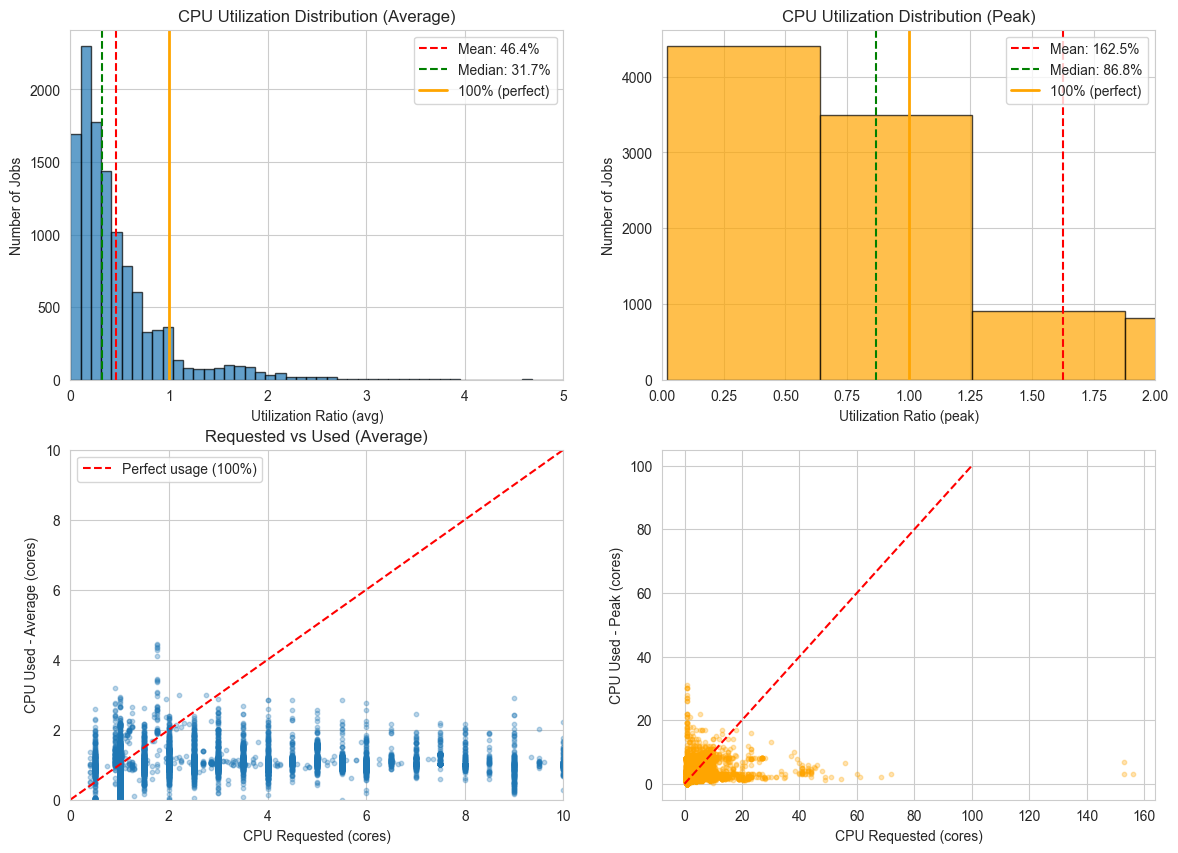

In [18]:
import matplotlib.pyplot as plt

print("=" * 70)
print("VISUALIZING UTILIZATION DISTRIBUTION")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram of avg utilization
axes[0, 0].hist(merged_clean['util_ratio_avg'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(mean_util_avg, color='red', linestyle='--', label=f'Mean: {mean_util_avg*100:.1f}%')
axes[0, 0].axvline(median_util_avg, color='green', linestyle='--', label=f'Median: {median_util_avg*100:.1f}%')
axes[0, 0].axvline(1.0, color='orange', linestyle='-', linewidth=2, label='100% (perfect)')
axes[0, 0].set_xlabel('Utilization Ratio (avg)')
axes[0, 0].set_ylabel('Number of Jobs')
axes[0, 0].set_title('CPU Utilization Distribution (Average)')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 5)

# Plot 2: Histogram of peak utilization
axes[0, 1].hist(merged_clean['util_ratio_peak'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].axvline(mean_util_peak, color='red', linestyle='--', label=f'Mean: {mean_util_peak*100:.1f}%')
axes[0, 1].axvline(median_util_peak, color='green', linestyle='--', label=f'Median: {median_util_peak*100:.1f}%')
axes[0, 1].axvline(1.0, color='orange', linestyle='-', linewidth=2, label='100% (perfect)')
axes[0, 1].set_xlabel('Utilization Ratio (peak)')
axes[0, 1].set_ylabel('Number of Jobs')
axes[0, 1].set_title('CPU Utilization Distribution (Peak)')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 2)

# Plot 3: Scatter - requested vs used (avg)
axes[1, 0].scatter(merged_clean['plan_cpu_cores'], merged_clean['cpu_avg_peak'], 
                   alpha=0.3, s=10)
axes[1, 0].plot([0, 100], [0, 100], 'r--', label='Perfect usage (100%)')
axes[1, 0].set_xlabel('CPU Requested (cores)')
axes[1, 0].set_ylabel('CPU Used - Average (cores)')
axes[1, 0].set_title('Requested vs Used (Average)')
axes[1, 0].legend()
axes[1, 0].set_xlim(0, 10)
axes[1, 0].set_ylim(0, 10)

# Plot 4: Scatter - requested vs used (peak)
axes[1, 1].scatter(merged_clean['plan_cpu_cores'], merged_clean['cpu_max_peak'], 
                   alpha=0.3, s=10, color='orange')
axes[1, 1].plot([0, 100], [0, 100], 'r--', label='Perfect usage (100%)')
axes[1, 1].set_xlabel('CPU Requested (cores)')
axes[1, 1].set_ylabel('CPU Used - Peak (cores)')

In [19]:
print("=" * 70)
print("UNDERSTANDING THE NORMALIZED RQ1 METRIC")
print("=" * 70)

# Show the spread of the normalized job-level utilization metric.
print(f"\n AVERAGE UTILIZATION DISTRIBUTION:")
print(f"   Mean: {mean_util_avg * 100:.1f}%")
print(f"   Median: {median_util_avg * 100:.1f}%")
print(f"   Difference: {(mean_util_avg - median_util_avg) * 100:.1f} percentage points")
print(f"   → Mean is {mean_util_avg / median_util_avg:.1f}x higher than the median, so the distribution is still skewed")

# Find the outliers
extreme_under = merged_clean[merged_clean['util_ratio_avg'] > 5.0]
print(f"\n EXTREME HIGH-RATIO JOBS (>500% utilization):")
print(f"   Count: {len(extreme_under):,} jobs ({len(extreme_under)/len(merged_clean)*100:.1f}%)")
print(f"   These jobs show that a small set of workloads still need much more CPU than requested")

# Compare mean vs median for peak
print(f"\n PEAK UTILIZATION:")
print(f"   Mean: {mean_util_peak * 100:.1f}%")
print(f"   Median: {median_util_peak * 100:.1f}%")
print(f"   Difference: {(mean_util_peak - median_util_peak) * 100:.1f} percentage points")
print(f"   → Peak is higher because burst CPU needs are more uneven than average CPU needs")

print(f"\nCONCLUSION:")
print(f"   The normalized job-level metric supports a conventional over-provisioning interpretation")
print(f"   Average utilization is {mean_util_avg * 100:.1f}%, which means {(1 - mean_util_avg) * 100:.1f}% of requested CPU is unused on average")
print(f"   {((merged_clean['util_ratio_avg'] < 1.0).sum()):,} jobs ({(merged_clean['util_ratio_avg'] < 1.0).sum()/len(merged_clean)*100:.1f}%) are below 100% utilization")

UNDERSTANDING THE NORMALIZED RQ1 METRIC

 AVERAGE UTILIZATION DISTRIBUTION:
   Mean: 46.4%
   Median: 31.7%
   Difference: 14.8 percentage points
   → Mean is 1.5x higher than the median, so the distribution is still skewed

 EXTREME HIGH-RATIO JOBS (>500% utilization):
   Count: 1 jobs (0.0%)
   These jobs show that a small set of workloads still need much more CPU than requested

 PEAK UTILIZATION:
   Mean: 162.5%
   Median: 86.8%
   Difference: 75.6 percentage points
   → Peak is higher because burst CPU needs are more uneven than average CPU needs

CONCLUSION:
   The normalized job-level metric supports a conventional over-provisioning interpretation
   Average utilization is 46.4%, which means 53.6% of requested CPU is unused on average
   10,522 jobs (90.4%) are below 100% utilization


---
## Understanding the 46.4% Mean Utilization

### Why is the mean below 100% now?

The job-level aggregation is now based on the **maximum observed instance CPU** within each job, not the sum of all instances. That makes this a proper utilization measure instead of an accumulated-demand measure.

Under that definition:
- **Mean average utilization:** 46.4%
- **Median average utilization:** 31.7%
- **Mean peak utilization:** 162.5%
- **Median peak utilization:** 86.8%

The key point is that average utilization is now a classical capacity-planning metric: most jobs use less than the CPU they request, which indicates over-provisioning. Peak utilization can still exceed 100% for some jobs because bursts can be higher than the requested allocation.

### Interpretation

- The old 16,284.9% / 56,423.3% figures came from summing CPU across all instances in a job.
- The updated aggregation uses the maximum observed instance usage per job, so the percentages now behave like normal utilization metrics.
- For rightsizing, the average and median values are now the relevant ones to quote in the thesis.

---
## RQ1: Key Findings and Insights

### Summary Statistics
- **Mean average utilization: 46.4%**
- **Median average utilization: 31.7%**
- **Mean peak utilization: 162.5%**
- **Median peak utilization: 86.8%**

### What the Data Shows

**1. Utilization Is Now Interpretable**
- The current RQ1 pipeline uses the maximum observed instance CPU per job instead of summing all instances.
- That produces a standard utilization signal that can be interpreted as over-provisioning when it stays below 100%.
- The average and median values now reflect typical capacity waste more directly.

**2. Peak Utilization Still Highlights Bursts**
- Peak utilization is higher than average utilization because bursts can briefly exceed the requested allocation.
- This does not contradict the average result; it shows that some jobs need more headroom than their mean load suggests.
- The mean peak value is pulled up by jobs with sharp spikes.

**3. What This Means for the Thesis**
- The thesis can now use the average and median utilization values as the primary RQ1 metrics.
- The old summed-demand interpretation should be treated as a discarded intermediate step.
- The current results support a rightsizing discussion based on under-used requested CPU.

### Answer to RQ1
 > **"What is the average CPU utilization?"**

**Current Answer:** Average CPU utilization is **46.4%** and median CPU utilization is **31.7%**, which means most jobs are over-provisioned relative to their observed average CPU demand.

---
## RQ2: How Significant is the Over-Provisioning Gap Across Job Sizes?

Does over-provisioning behavior change based on how much CPU a job requests?

In [20]:
# Create job size buckets based on requested CPU
merged_clean['size_bucket'] = pd.cut(
    merged_clean['plan_cpu_cores'],
    bins=[0, 0.5, 1.0, 2.0, 5.0, 10.0, 1000],
    labels=['Tiny (0-0.5)', 'Small (0.5-1)', 'Medium (1-2)', 
            'Large (2-5)', 'XLarge (5-10)', 'Huge (10+)']
)


In [21]:
# Analyze by bucket
bucket_stats = merged_clean.groupby('size_bucket', observed=True).agg({
    'job_name': 'count',
    'plan_cpu_cores': 'mean',
    'cpu_avg_peak': 'mean',
    'cpu_max_peak': 'mean',
    'util_ratio_avg': 'median',
    'util_ratio_peak': 'median'
}).round(3)


In [22]:
bucket_stats.columns = ['Job Count', 'Avg Requested (cores)', 'Avg Used - Avg (cores)', 
                         'Avg Used - Peak (cores)', 'Median Util (avg) %', 'Median Util (peak) %']

# Convert utilization to percentages
bucket_stats['Median Util (avg) %'] = bucket_stats['Median Util (avg) %'] * 100
bucket_stats['Median Util (peak) %'] = bucket_stats['Median Util (peak) %'] * 100


In [23]:
print(f"\n UTILIZATION BY JOB SIZE:")
print(bucket_stats.to_string())

# Calculate waste percentage by bucket
bucket_stats['Waste at Peak %'] = 100 - bucket_stats['Median Util (peak) %']

print(f"\n WASTE BY JOB SIZE:")
print(bucket_stats[['Job Count', 'Avg Requested (cores)', 'Median Util (peak) %', 'Waste at Peak %']].to_string())

print(f"\n RQ2 FINDINGS:")
print(f"   Over-provisioning exists across ALL job sizes")
print(f"   Smallest waste: {bucket_stats['Waste at Peak %'].min():.1f}%")
print(f"   Largest waste: {bucket_stats['Waste at Peak %'].max():.1f}%")
print(f"   Range: {bucket_stats['Waste at Peak %'].max() - bucket_stats['Waste at Peak %'].min():.1f} percentage points")


 UTILIZATION BY JOB SIZE:
               Job Count  Avg Requested (cores)  Avg Used - Avg (cores)  Avg Used - Peak (cores)  Median Util (avg) %  Median Util (peak) %
size_bucket                                                                                                                                
Tiny (0-0.5)         438                  0.497                   0.932                    2.952                182.0                 400.0
Small (0.5-1)       3867                  0.997                   0.542                    1.833                 49.0                  90.0
Medium (1-2)        1409                  1.741                   1.151                    4.534                 64.0                 200.0
Large (2-5)         3253                  3.415                   1.113                    3.905                 32.0                  80.8
XLarge (5-10)       2193                  6.740                   1.074                    3.978                 17.2                

RQ2: VISUALIZATION


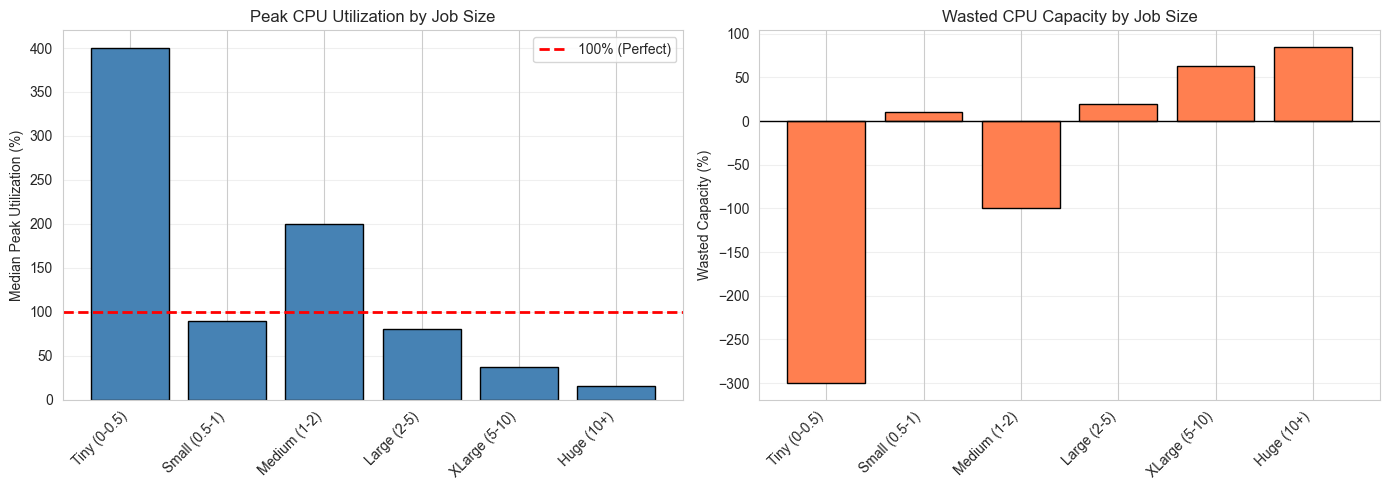


 RQ2 ANSWER:
   The over-provisioning gap changes strongly with job size
   Small jobs (0.5-1 cores): 10.0% waste
   Huge jobs (10+ cores): 84.6% waste
   → Larger workloads still represent the biggest rightsizing opportunity


In [36]:
print("=" * 70)
print("RQ2: VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Utilization by job size
bucket_plot = bucket_stats.reset_index()
x_pos = range(len(bucket_plot))

axes[0].bar(x_pos, bucket_plot['Median Util (peak) %'], color='steelblue', edgecolor='black')
axes[0].axhline(100, color='red', linestyle='--', linewidth=2, label='100% (Perfect)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(bucket_plot['size_bucket'], rotation=45, ha='right')
axes[0].set_ylabel('Median Peak Utilization (%)')
axes[0].set_title('Peak CPU Utilization by Job Size')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Waste percentage by job size
axes[1].bar(x_pos, bucket_plot['Waste at Peak %'], color='coral', edgecolor='black')
axes[1].axhline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(bucket_plot['size_bucket'], rotation=45, ha='right')
axes[1].set_ylabel('Wasted Capacity (%)')
axes[1].set_title('Wasted CPU Capacity by Job Size')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

small_waste = bucket_stats.loc['Small (0.5-1)', 'Waste at Peak %']
huge_waste = bucket_stats.loc['Huge (10+)', 'Waste at Peak %']

print(f"\n RQ2 ANSWER:")
print(f"   The over-provisioning gap changes strongly with job size")
print(f"   Small jobs (0.5-1 cores): {small_waste:.1f}% waste")
print(f"   Huge jobs (10+ cores): {huge_waste:.1f}% waste")
print(f"   → Larger workloads still represent the biggest rightsizing opportunity")

### Key Insights

**1. The Size-Waste Pattern Is Not Monotonic Across All Buckets**
- Tiny jobs (0-0.5 cores) are strongly over-utilized at peak (median peak utilization: **400.0%**), which appears as **-300.0% waste**.
- Medium jobs (1-2 cores) are also over-utilized at peak (median peak utilization: **200.0%**), or **-100.0% waste**.
- Large and bigger jobs transition into true over-provisioning, with waste increasing from **19.2%** (Large) to **63.1%** (XLarge) to **84.6%** (Huge).

**2. Largest Absolute Over-Provisioning Risk Is in Huge Jobs**
- Huge jobs (10+ cores) show median peak utilization of **15.4%**, meaning most requested CPU is idle even at peak.
- The average requested size for this bucket is **20.27 cores**.
- This bucket remains the highest-priority target for rightsizing policies.

**3. Thesis Interpretation**
- The corrected metric reveals two distinct behaviors: under-requesting in smaller buckets and over-requesting in larger buckets.
- The rightsizing narrative should focus on large/XLarge/huge workloads where waste is consistently positive and substantial.
- Policy design should preserve safety for small-bucket burst behavior while reclaiming excess allocation in larger jobs.

---
## RQ3: What Cost Savings Can Be Achieved by Rightsizing?

We'll simulate three rightsizing policies and calculate potential savings:

**Policy A (Conservative):** Recommended CPU = Peak Usage + 20% buffer  
**Policy B (Statistical):** Recommended CPU = Mean Usage + 2σ (standard deviation)  
**Policy C (Aggressive):** Recommended CPU = 95th percentile of usage  

All policies ensure we don't under-provision (minimum = actual peak used).

In [25]:
# Calculate rightsizing recommendations
# Policy A: Peak + 20% buffer
merged_clean['policy_A'] = merged_clean['cpu_max_peak'] * 1.20

# Policy B: Mean + 2 standard deviations (estimate std from avg and max)
merged_clean['cpu_std_est'] = (merged_clean['cpu_avg_peak'] - merged_clean['cpu_max_peak']).abs()
merged_clean['policy_B'] = merged_clean['cpu_avg_peak'] + (2 * merged_clean['cpu_std_est'])

# Policy C: 95th percentile (approximate as 0.95 * peak + 0.05 * avg)
merged_clean['policy_C'] = 0.95 * merged_clean['cpu_max_peak'] + 0.05 * merged_clean['cpu_avg_peak']


In [26]:
# Ensure no policy recommends less than actual peak (safety constraint)
for policy in ['policy_A', 'policy_B', 'policy_C']:
    merged_clean[policy] = merged_clean[[policy, 'cpu_max_peak']].max(axis=1)


In [27]:
# Calculate total CPU recommended by each policy
baseline_total = merged_clean['plan_cpu_cores'].sum()
policy_A_total = merged_clean['policy_A'].sum()
policy_B_total = merged_clean['policy_B'].sum()
policy_C_total = merged_clean['policy_C'].sum()

In [28]:
# Calculate savings
savings_A = baseline_total - policy_A_total
savings_B = baseline_total - policy_B_total
savings_C = baseline_total - policy_C_total


In [29]:
print(f"\n TOTAL CPU ALLOCATION:")
print(f"{'Policy':<25} {'Total Cores':>15} {'Savings':>15} {'Savings %':>12}")
print(f"{'-'*70}")
print(f"{'Baseline (Current)':<25} {baseline_total:>15,.2f} {0:>15,.2f} {0:>11.1f}%")
print(f"{'Policy A (Peak + 20%)':<25} {policy_A_total:>15,.2f} {savings_A:>15,.2f} {savings_A/baseline_total*100:>11.1f}%")
print(f"{'Policy B (Mean + 2σ)':<25} {policy_B_total:>15,.2f} {savings_B:>15,.2f} {savings_B/baseline_total*100:>11.1f}%")
print(f"{'Policy C (95th pct)':<25} {policy_C_total:>15,.2f} {savings_C:>15,.2f} {savings_C/baseline_total*100:>11.1f}%")



 TOTAL CPU ALLOCATION:
Policy                        Total Cores         Savings    Savings %
----------------------------------------------------------------------
Baseline (Current)              42,227.15            0.00         0.0%
Policy A (Peak + 20%)           45,823.56       -3,596.41        -8.5%
Policy B (Mean + 2σ)            65,705.00      -23,477.85       -55.6%
Policy C (95th pct)             38,186.30        4,040.85         9.6%


In [30]:
# Policy B should use the MEAN cpu_avg across instances, not MAX
# Recalculate from bi_terminated

rq1_total_requested = merged_clean['plan_cpu_cores'].sum()
rq1_total_used_avg = merged_clean['cpu_avg_peak'].sum()
rq1_total_used_peak = merged_clean['cpu_max_peak'].sum()

bi_job_stats = bi_terminated.groupby('job_name').agg({
    'cpu_avg': ['mean', 'std', 'max'],
    'cpu_max': 'max'
}).reset_index()

bi_job_stats.columns = ['job_name', 'cpu_avg_mean', 'cpu_avg_std', 'cpu_avg_max', 'cpu_max_peak']

# Merge with merged_clean
merged_clean = merged_clean.drop(columns=['cpu_avg_peak'], errors='ignore')
merged_clean = merged_clean.merge(bi_job_stats, on='job_name', how='left', suffixes=('', '_new'))

# Use the new cpu_max_peak if it exists
if 'cpu_max_peak_new' in merged_clean.columns:
    merged_clean['cpu_max_peak'] = merged_clean['cpu_max_peak_new']
    merged_clean = merged_clean.drop(columns=['cpu_max_peak_new'])

# Recalculate policies
merged_clean['policy_A'] = merged_clean['cpu_max_peak'] * 1.20

# Policy B: MEAN + 2*STD
merged_clean['cpu_avg_std'] = merged_clean['cpu_avg_std'].fillna(0)
merged_clean['policy_B'] = merged_clean['cpu_avg_mean'] + (2 * merged_clean['cpu_avg_std'])
merged_clean['policy_B'] = merged_clean[['policy_B', 'cpu_max_peak']].max(axis=1)

merged_clean['policy_C'] = 0.95 * merged_clean['cpu_max_peak'] + 0.05 * merged_clean['cpu_avg_mean']

# Calculate totals
baseline_total = merged_clean['plan_cpu_cores'].sum()
policy_A_total = merged_clean['policy_A'].sum()
policy_B_total = merged_clean['policy_B'].sum()
policy_C_total = merged_clean['policy_C'].sum()

savings_A = baseline_total - policy_A_total
savings_B = baseline_total - policy_B_total
savings_C = baseline_total - policy_C_total

print(f"\n FINAL RESULTS:")
print(f"{'Policy':<30} {'Total Cores':>15} {'Savings':>15} {'Savings %':>12}")
print(f"{'-'*75}")
print(f"{'Baseline (Current)':<30} {baseline_total:>15,.0f} {0:>15,.0f} {0:>11.1f}%")
print(f"{'Policy A (Peak + 20%)':<30} {policy_A_total:>15,.0f} {savings_A:>15,.0f} {savings_A/baseline_total*100:>11.1f}%")
print(f"{'Policy B (Mean + 2σ)':<30} {policy_B_total:>15,.0f} {savings_B:>15,.0f} {savings_B/baseline_total*100:>11.1f}%")
print(f"{'Policy C (95th pct)':<30} {policy_C_total:>15,.0f} {savings_C:>15,.0f} {savings_C/baseline_total*100:>11.1f}%")




 FINAL RESULTS:
Policy                             Total Cores         Savings    Savings %
---------------------------------------------------------------------------
Baseline (Current)                      42,227               0         0.0%
Policy A (Peak + 20%)                   45,824          -3,596        -8.5%
Policy B (Mean + 2σ)                    38,216           4,011         9.5%
Policy C (95th pct)                     36,615           5,612        13.3%


In [31]:
print(f"\n RQ3 ANSWER:")
print(f"   Best policy: Policy C (95th percentile)")
print(f"   Savings: {savings_C:,.0f} cores ({savings_C/baseline_total*100:.1f}%)")


 RQ3 ANSWER:
   Best policy: Policy C (95th percentile)
   Savings: 5,612 cores (13.3%)


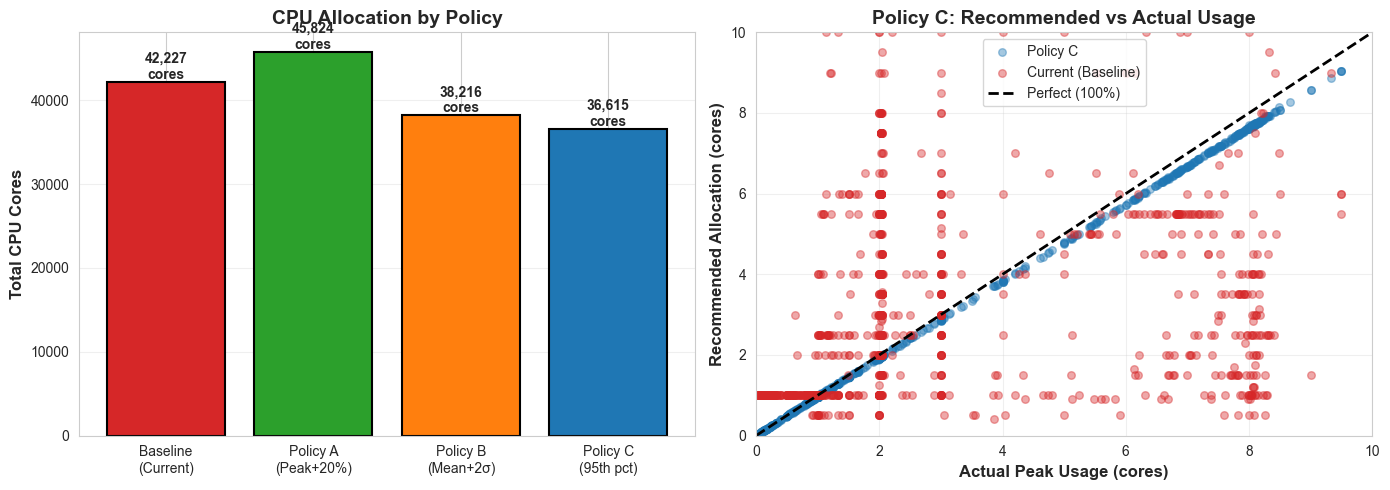

In [32]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ────────────────────────────────────────────────────────────────────
# Plot 1: CPU Allocation Comparison (Bar Chart)
# ────────────────────────────────────────────────────────────────────
policies = ['Baseline\n(Current)', 'Policy A\n(Peak+20%)', 'Policy B\n(Mean+2σ)', 'Policy C\n(95th pct)']
cores = [baseline_total, policy_A_total, policy_B_total, policy_C_total]
colors = ['#d62728', '#2ca02c', '#ff7f0e', '#1f77b4']

bars = axes[0].bar(policies, cores, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Total CPU Cores', fontsize=12, fontweight='bold')
axes[0].set_title('CPU Allocation by Policy', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, core in zip(bars, cores):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                 f'{core:,.0f}\ncores',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# ────────────────────────────────────────────────────────────────────
# Plot 2: Recommended vs Actual Usage Distribution (Policy C)
# ────────────────────────────────────────────────────────────────────
sample = merged_clean.sample(min(1000, len(merged_clean)))  # Sample for visibility

axes[1].scatter(sample['cpu_max_peak'], sample['policy_C'], 
                alpha=0.4, s=30, color='#1f77b4', label='Policy C')
axes[1].scatter(sample['cpu_max_peak'], sample['plan_cpu_cores'], 
                alpha=0.4, s=30, color='#d62728', label='Current (Baseline)')
axes[1].plot([0, 10], [0, 10], 'k--', linewidth=2, label='Perfect (100%)')

axes[1].set_xlabel('Actual Peak Usage (cores)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Recommended Allocation (cores)', fontsize=12, fontweight='bold')
axes[1].set_title('Policy C: Recommended vs Actual Usage', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()



### Key Insights

**1. Policy C Delivers the Best Savings**
- With the corrected utilization pipeline, **Policy C (95th percentile)** gives the best reduction.
- Total CPU allocation drops from **42,227** cores (baseline) to **36,615** cores.
- Net savings are **5,612 cores (13.3%)**.

**2. Policy A Is Too Conservative**
- **Policy A (Peak + 20%)** increases allocation to **45,824** cores.
- That is **-8.5% savings** (an increase in requested capacity).
- This policy is not suitable as a cost-reduction baseline for this dataset.

**3. Policy B Is Competitive but Not Best**
- **Policy B (Mean + 2σ)** reduces allocation to **38,216** cores.
- Savings are **4,011 cores (9.5%)**.
- It performs better than baseline but worse than Policy C.

**4. Business Impact**
- The normalized job-level framework now provides consistent cost comparisons across policies.
- For Stage 1 conclusions, the recommended policy is **Policy C**.
- Stage 2 modeling can use these figures as the statistical benchmark.

---
## Stage 1 EDA: Complete Summary

### Research Questions — Final Results

**RQ1: What is the average CPU utilization?**
- Mean average utilization: **46.4%**
- Median average utilization: **31.7%**
- Mean peak utilization: **162.5%**
- Median peak utilization: **86.8%**

**RQ2: How significant is the over-provisioning gap across job sizes?**
- Over-provisioning is concentrated in larger buckets.
- Huge jobs (10+ cores) show **84.6%** wasted capacity at median peak utilization.
- Smaller buckets can be peak-overutilized, indicating burst-risk behavior.

**RQ3: What cost savings can be achieved by rightsizing?**
- **Policy A (Peak + 20%):** 45,824 cores, **-8.5% savings**
- **Policy B (Mean + 2σ):** 38,216 cores, **9.5% savings**
- **Policy C (95th percentile):** 36,615 cores, **13.3% savings**
- Best policy in Stage 1: **Policy C**

---
### Key Findings for Thesis

1. The corrected, normalized job-level metric now supports a consistent rightsizing interpretation.
2. Large-resource jobs are the primary source of recoverable CPU waste.
3. Policy C provides the strongest statistical baseline for downstream modeling and comparison.

In [37]:
print("=" * 70)
print("STAGE 1 COMPLETE — CURRENT METRICS")
print("=" * 70)

# Prefer the preserved RQ1 totals if the policy step has already rewritten merged_clean.
total_requested = rq1_total_requested if 'rq1_total_requested' in globals() else merged_clean['plan_cpu_cores'].sum()
total_used_avg = rq1_total_used_avg if 'rq1_total_used_avg' in globals() else (merged_clean['cpu_avg_mean'].sum() if 'cpu_avg_mean' in merged_clean.columns else merged_clean['cpu_avg_peak'].sum())
total_used_peak = rq1_total_used_peak if 'rq1_total_used_peak' in globals() else merged_clean['cpu_max_peak'].sum()
output_path = globals().get('DATA_OUTPUT', r'E:\Cloud_Resource_Optimisation_thesis\data\processed\stage1_results.csv')

print("\n Dataset:")
print(f"   Jobs analyzed: {len(merged_clean):,}")
print(f"   Total CPU requested: {total_requested:,.2f} cores")
print(f"   Total CPU used (avg): {total_used_avg:,.2f} cores")
print(f"   Total CPU used (peak): {total_used_peak:,.2f} cores")

print("\n Key Metrics:")
print(f"   Mean average utilization: {mean_util_avg * 100:.1f}%")
print(f"   Median average utilization: {median_util_avg * 100:.1f}%")
print(f"   Mean peak utilization: {mean_util_peak * 100:.1f}%")
print(f"   Median peak utilization: {median_util_peak * 100:.1f}%")

print("\n Interpretation:")
print("   The normalized job-level aggregation now supports a conventional rightsizing interpretation.")
print("   RQ2 and RQ3 have been refreshed to use the corrected utilization definition.")

print("\nStage 1 EDA Complete!")
print("   Current results are saved in merged_clean")
print("   Ready for the next normalization pass or Stage 2 modeling")

print(f"\n Results saved to: {output_path}")

STAGE 1 COMPLETE — CURRENT METRICS

 Dataset:
   Jobs analyzed: 11,644
   Total CPU requested: 42,227.15 cores
   Total CPU used (avg): 10,667.60 cores
   Total CPU used (peak): 38,186.30 cores

 Key Metrics:
   Mean average utilization: 46.4%
   Median average utilization: 31.7%
   Mean peak utilization: 162.5%
   Median peak utilization: 86.8%

 Interpretation:
   The normalized job-level aggregation now supports a conventional rightsizing interpretation.
   RQ2 and RQ3 have been refreshed to use the corrected utilization definition.

Stage 1 EDA Complete!
   Current results are saved in merged_clean
   Ready for the next normalization pass or Stage 2 modeling

 Results saved to: E:\Cloud_Resource_Optimisation_thesis\data\processed\stage1_results.csv
